**Program-2:**

Dataset (https://archive.ics.uci.edu/ml/datasets/heart+disease)

(a) Analyze and visualize the dataset to understand patterns and relationships among clinical features and heart disease outcomes.

(b) Build a classification model using Logistic Regression and apply a variant approach using
Multinomial Logistic Regression.

(c) Evaluate and interpret the model performance using Accuracy, Precision, Recall, F1-score, and ROC-
AUC metrics.

In [ ]:
pip install ucimlrepo

In [ ]:
# Heart Disease Analysis using Logistic Regression
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)
heart_disease = fetch_ucirepo(id=45)

X = heart_disease.data.features
y = heart_disease.data.targets

data = pd.concat([X, y], axis=1)

print("First 5 rows:")
print(data.head(50))

print("\nDataset Shape:")
print(data.shape)



First 5 rows:
    age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
0    63    1   1       145   233    1        2      150      0      2.3   
1    67    1   4       160   286    0        2      108      1      1.5   
2    67    1   4       120   229    0        2      129      1      2.6   
3    37    1   3       130   250    0        0      187      0      3.5   
4    41    0   2       130   204    0        2      172      0      1.4   
5    56    1   2       120   236    0        0      178      0      0.8   
6    62    0   4       140   268    0        2      160      0      3.6   
7    57    0   4       120   354    0        0      163      1      0.6   
8    63    1   4       130   254    0        2      147      0      1.4   
9    53    1   4       140   203    1        2      155      1      3.1   
10   57    1   4       140   192    0        0      148      0      0.4   
11   56    0   2       140   294    0        2      153      0      1.3   
12   56    

In [ ]:
data = data.fillna(data.median(numeric_only=True))

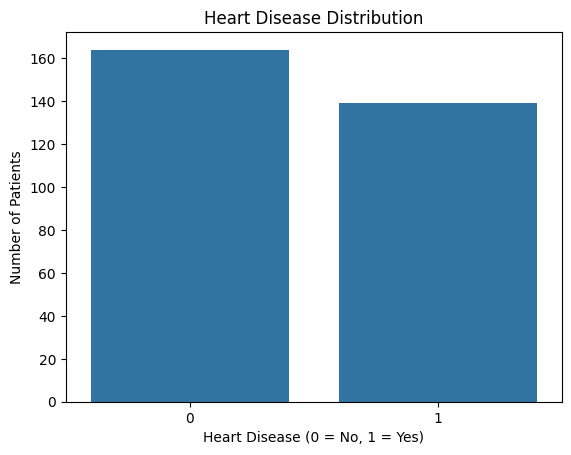

In [ ]:
data["target"] = data["num"].apply(lambda x: 1 if x > 0 else 0)
sns.countplot(x="target", data=data)
plt.title("Heart Disease Distribution")
plt.xlabel("Heart Disease (0 = No, 1 = Yes)")
plt.ylabel("Number of Patients")
plt.show()

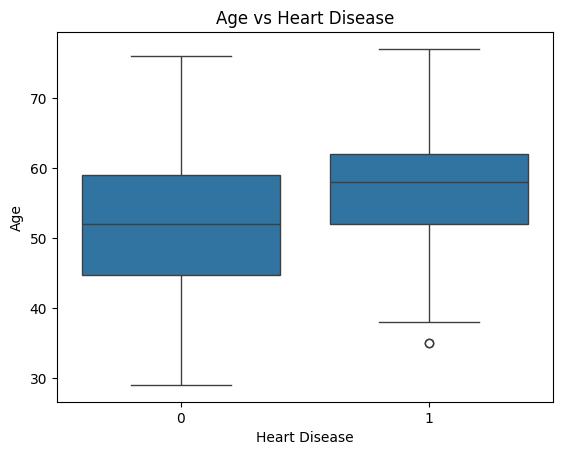

In [ ]:
# Age vs Heart Disease
sns.boxplot(x="target", y="age", data=data)
plt.title("Age vs Heart Disease")
plt.xlabel("Heart Disease")
plt.ylabel("Age")
plt.show()


LOGISTIC REGRESSION RESULTS
Accuracy : 0.8852459016393442
Precision: 0.8787878787878788
Recall   : 0.90625
F1 Score : 0.8923076923076924
ROC-AUC  : 0.9213362068965517


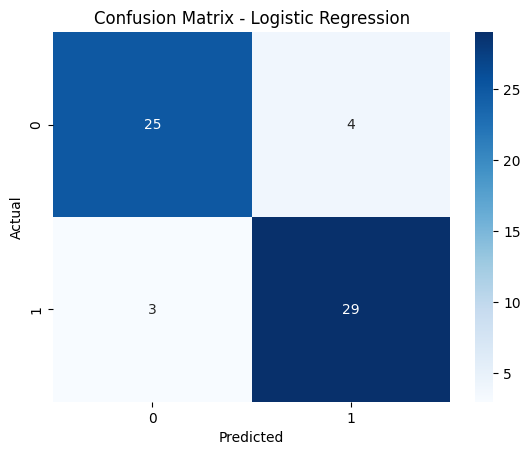

In [ ]:

#  Binary Logistic Regression
X = data.drop(["num", "target"], axis=1)
y = data["target"]
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Probability for ROC-AUC
y_prob = model.predict_proba(X_test)[:, 1]
print("\n===================================")
print("LOGISTIC REGRESSION RESULTS")
print("===================================")
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()



MULTINOMIAL LOGISTIC REGRESSION
Accuracy : 0.5409836065573771
Precision: 0.3152777777777778
Recall   : 0.3308976464148878
F1 Score : 0.3170415108810277


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


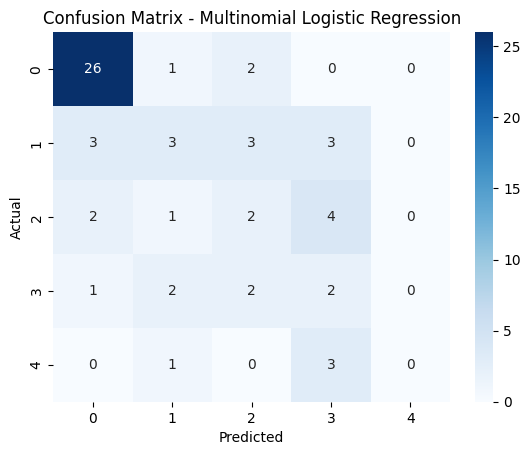

In [ ]:
# Multinomial Logistic Regression
# Original target values: 0, 1, 2, 3, 4
X = data.drop(["num", "target"], axis=1)
y = data["num"]
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)
# Scale data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
# Create Multinomial Logistic Regression model
multi_model = LogisticRegression(
    multi_class="multinomial",
    max_iter=1000
)
# Train model
multi_model.fit(X_train, y_train)
# Prediction
y_pred_multi = multi_model.predict(X_test)
#  Evaluate Multinomial Logistic Regression
print("\n===================================")
print("MULTINOMIAL LOGISTIC REGRESSION")
print("===================================")
print(
    "Accuracy :",
    accuracy_score(y_test, y_pred_multi)
)
print(
    "Precision:",
    precision_score(
        y_test,
        y_pred_multi,
        average="macro",
        zero_division=0
    )
)

print(
    "Recall   :",
    recall_score(
        y_test,
        y_pred_multi,
        average="macro",
        zero_division=0
    )
)

print(
    "F1 Score :",
    f1_score(
        y_test,
        y_pred_multi,
        average="macro",
        zero_division=0
    )
)
# Confusion Matrix
cm_multi = confusion_matrix(y_test, y_pred_multi)

sns.heatmap(
    cm_multi,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.title("Confusion Matrix - Multinomial Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
